# Lab 6: Spinning & Rolling Objects

Name: 
Date: 
Lab: PHYS 311 Module 6

This notebook simulates a physical pendulum, races three rolling shapes down an incline, and demonstrates angular momentum conservation with a variable-inertia spinning body.

**AI use disclaimer:** AI (Claude) was used in preparing this notebook for coding assistance, tidying up code, and improving code flow/organization. This is not to say that there was no human work done in this code; all lines included input and assistance from myself and many iterations and human attempts are consolidated into the notebook seen below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part A: The Physical Pendulum

A uniform rod of length L pivots about one end under gravity. This is the rotational version of the oscillator from Lab 3, just with torque instead of force.

In [2]:
m, g, d = 1.0, 9.81, 0.5
I = (1 / 3) * m * (2 * d)**2
Omega = np.sqrt(m * g * d / I)

def torque(theta):
    return -m * g * d * np.sin(theta)

def rotate_step(theta, omega, trq, I, dt):
    alpha = trq / I
    omega = omega + alpha * dt
    theta = theta + omega * dt
    return theta, omega

def simulate_pendulum(theta0, dt=0.001, t_max=8.0):
    theta, omega = theta0, 0.0
    thetas = [theta]
    for _ in range(int(t_max / dt)):
        theta, omega = rotate_step(theta, omega, torque(theta), I, dt)
        thetas.append(theta)
    return np.array(thetas)

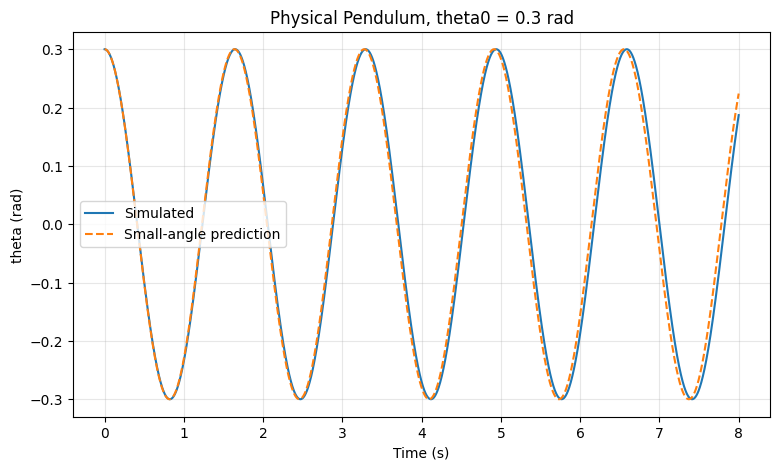

In [3]:
dt = 0.001
t_max = 8.0
t_arr = np.arange(0, t_max + dt, dt)

theta0 = 0.3
thetas = simulate_pendulum(theta0, dt, t_max)
small_angle = theta0 * np.cos(Omega * t_arr)

plt.figure(figsize=(9, 5))
plt.plot(t_arr, thetas, label='Simulated')
plt.plot(t_arr, small_angle, '--', label='Small-angle prediction')
plt.xlabel('Time (s)')
plt.ylabel('theta (rad)')
plt.title('Physical Pendulum, theta0 = 0.3 rad')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

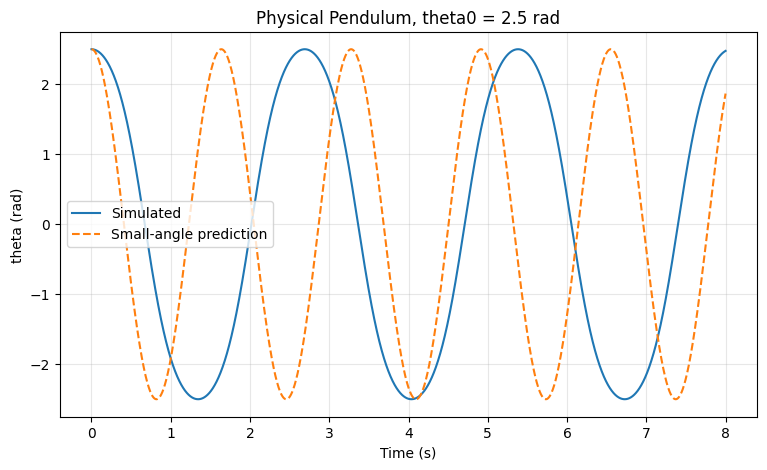

In [4]:
theta0 = 2.5
thetas = simulate_pendulum(theta0, dt, t_max)
small_angle = theta0 * np.cos(Omega * t_arr)

plt.figure(figsize=(9, 5))
plt.plot(t_arr, thetas, label='Simulated')
plt.plot(t_arr, small_angle, '--', label='Small-angle prediction')
plt.xlabel('Time (s)')
plt.ylabel('theta (rad)')
plt.title('Physical Pendulum, theta0 = 2.5 rad')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

At theta0 = 0.3 rad, the real swing tracks the small-angle prediction closely, both have almost the same period. At theta0 = 2.5 rad, the real swing falls badly out of step with the small-angle curve, stretching out to a noticeably longer period. This is the same effect as the nonlinear pendulum in Lab 3. Away from small angles, sin(theta) is smaller than theta, so the restoring torque is weaker than the small-angle formula assumes, and the swing takes longer than predicted.

## Part B: The Rolling Race

A hoop, a disk, and a solid sphere roll without slipping down the same incline. The acceleration only depends on the shape factor c = I / (m R^2), not on mass or radius.

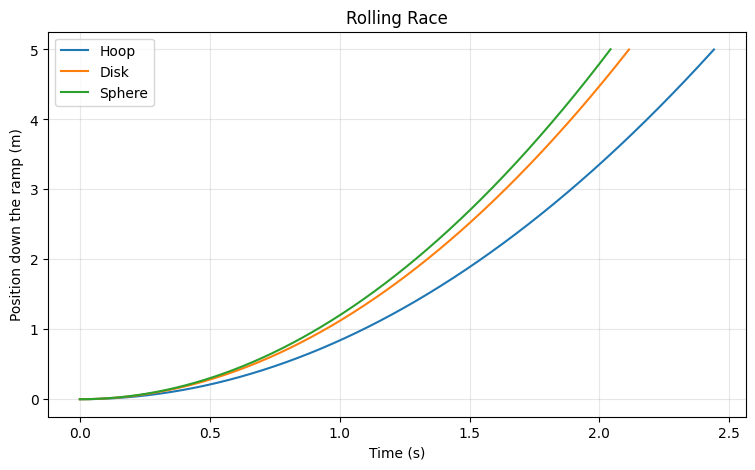

Sphere: finish time = 2.0430 s
Disk: finish time = 2.1140 s
Hoop: finish time = 2.4410 s


In [5]:
incline = np.radians(20.0)
ramp_length = 5.0

def simulate_roll(c, dt=0.001, L=ramp_length):
    a = g * np.sin(incline) / (1 + c)
    x, v = 0.0, 0.0
    xs, ts = [x], [0.0]
    t = 0.0
    while x < L:
        v = v + a * dt
        x = x + v * dt
        t = t + dt
        xs.append(x)
        ts.append(t)
    return np.array(ts), np.array(xs), v

shapes = {'Hoop': 1.0, 'Disk': 0.5, 'Sphere': 0.4}

plt.figure(figsize=(9, 5))
finish_times = {}
for name, c in shapes.items():
    ts, xs, v_final = simulate_roll(c)
    finish_times[name] = ts[-1]
    plt.plot(ts, xs, label=name)
plt.xlabel('Time (s)')
plt.ylabel('Position down the ramp (m)')
plt.title('Rolling Race')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for name in ['Sphere', 'Disk', 'Hoop']:
    print(f"{name}: finish time = {finish_times[name]:.4f} s")

Finish order is sphere, then disk, then hoop, matching the shape factor order c = 0.4, 0.5, 1.0. This holds no matter what mass or radius is used, because both the driving gravity term and the inertia term scale with mass, so mass cancels completely out of the acceleration. Only the shape, how far the mass sits from the rotation axis on average, decides the race.

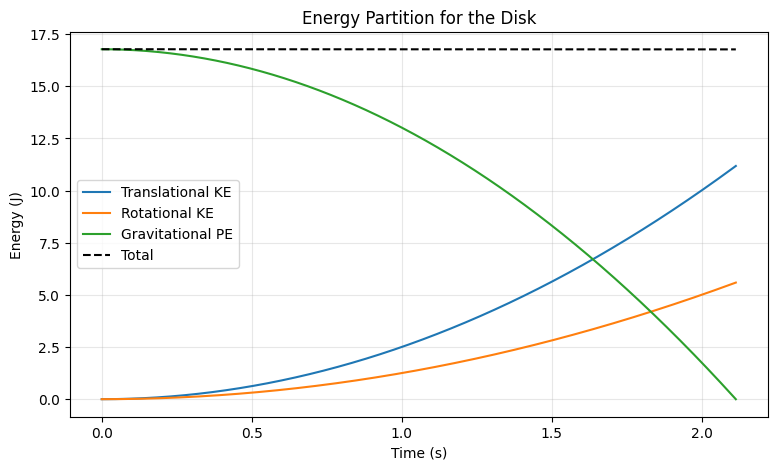

Total energy: start = 16.7761 J, end = 16.7682 J
Fraction of kinetic energy in rotation at the bottom: 0.3333
Expected c / (1 + c) = 0.3333


In [6]:
m_disk, R = 1.0, 0.1
c = 0.5
I_disk = c * m_disk * R**2

a = g * np.sin(incline) / (1 + c)
dt = 0.001
x, v = 0.0, 0.0
xs, vs = [x], [v]
while x < ramp_length:
    v = v + a * dt
    x = x + v * dt
    xs.append(x)
    vs.append(v)
xs, vs = np.array(xs), np.array(vs)

omegas = vs / R
KE_trans = 0.5 * m_disk * vs**2
KE_rot = 0.5 * I_disk * omegas**2
PE = m_disk * g * np.sin(incline) * (ramp_length - xs)
E_total = KE_trans + KE_rot + PE

t_roll = np.arange(len(xs)) * dt

plt.figure(figsize=(9, 5))
plt.plot(t_roll, KE_trans, label='Translational KE')
plt.plot(t_roll, KE_rot, label='Rotational KE')
plt.plot(t_roll, PE, label='Gravitational PE')
plt.plot(t_roll, E_total, 'k--', label='Total')
plt.xlabel('Time (s)')
plt.ylabel('Energy (J)')
plt.title('Energy Partition for the Disk')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

frac_rot = KE_rot[-1] / (KE_rot[-1] + KE_trans[-1])
print(f"Total energy: start = {E_total[0]:.4f} J, end = {E_total[-1]:.4f} J")
print(f"Fraction of kinetic energy in rotation at the bottom: {frac_rot:.4f}")
print(f"Expected c / (1 + c) = {c / (1 + c):.4f}")

Total energy stays essentially constant the whole way down, gravitational PE converting into translational and rotational KE together. For the disk, almost exactly one third of the kinetic energy at the bottom is rotational, matching c / (1 + c) with c = 0.5. The sphere would send less into rotation and the hoop would send more, which is exactly why the sphere wins, more of its energy budget goes into moving forward instead of spinning.

## Part C: Angular Momentum Conservation

A spinning body with no external torque keeps L = I*omega fixed even while I changes. This is the skater pulling in their arms.

In [7]:
I0, omega0 = 1.0, 2.0
L0 = I0 * omega0

dt = 0.001
t1, t2, t_end = 2.0, 3.0, 5.0

t_arr = np.arange(0, t_end + dt, dt)
I_arr = np.zeros_like(t_arr)
for i, t in enumerate(t_arr):
    if t < t1:
        I_arr[i] = I0
    elif t < t2:
        frac = (t - t1) / (t2 - t1)
        I_arr[i] = I0 - frac * (I0 - I0 / 2)
    else:
        I_arr[i] = I0 / 2

omega_arr = L0 / I_arr
L_arr = I_arr * omega_arr
KE_arr = 0.5 * I_arr * omega_arr**2

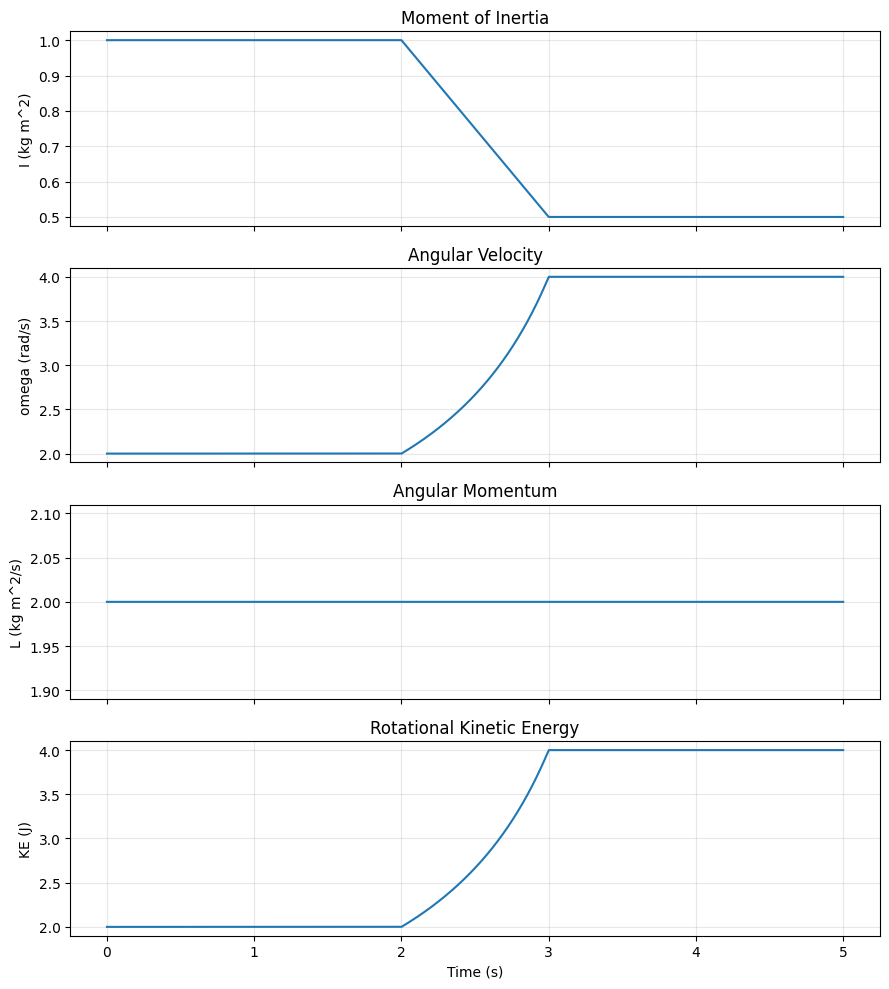

L before = 2.0000, L after = 2.0000
omega before = 2.0000, omega after = 4.0000
KE before = 2.0000, KE after = 4.0000


In [8]:
fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

axes[0].plot(t_arr, I_arr)
axes[0].set_ylabel('I (kg m^2)')
axes[0].set_title('Moment of Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(t_arr, omega_arr)
axes[1].set_ylabel('omega (rad/s)')
axes[1].set_title('Angular Velocity')
axes[1].grid(alpha=0.3)

axes[2].plot(t_arr, L_arr)
axes[2].set_ylabel('L (kg m^2/s)')
axes[2].set_title('Angular Momentum')
axes[2].grid(alpha=0.3)

axes[3].plot(t_arr, KE_arr)
axes[3].set_ylabel('KE (J)')
axes[3].set_title('Rotational Kinetic Energy')
axes[3].set_xlabel('Time (s)')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"L before = {L_arr[0]:.4f}, L after = {L_arr[-1]:.4f}")
print(f"omega before = {omega_arr[0]:.4f}, omega after = {omega_arr[-1]:.4f}")
print(f"KE before = {KE_arr[0]:.4f}, KE after = {KE_arr[-1]:.4f}")

L stays exactly fixed the whole time, since nothing external is twisting the skater. Pulling the arms in halves I, and since omega = L/I, omega doubles to keep L the same. KE = 0.5*I*omega^2 does not stay fixed though, it doubles along with omega. That extra kinetic energy is not free. Pulling the arms inward against their own outward-flung motion takes muscular effort, and that effort is exactly where the extra energy comes from. Angular momentum only cares about external torque, and there is none here, but kinetic energy responds to any work done on the body, internal or external, so the two quantities are allowed to behave differently.

**Three conservation laws, three diagnostics.**

- Energy (Block 1): a numerical integrator that quietly adds or removes energy, such as standard Euler spiraling an oscillator outward, is caught by an energy plot that drifts when it should stay flat.
- Linear momentum (Week 4): a collision routine with a sign error or a bad restitution formula shows up as total momentum changing across a collision when nothing external pushed on the system.
- Angular momentum (Week 6): a force that is not perfectly central, say a gravity vector computed slightly off from the line to the star, shows up as L slowly drifting even though no real torque should be acting.

## Bonus: Rolling Meets Collisions

The disk from Part B reaches the bottom of the ramp still rolling, then hits a stationary block on the flat ground.

In [9]:
def collide_1d(m1, m2, u1, u2, e=1.0):
    total_m = m1 + m2
    v_cm = (m1 * u1 + m2 * u2) / total_m
    v1 = v_cm - e * (m2 / total_m) * (u1 - u2)
    v2 = v_cm + e * (m1 / total_m) * (u1 - u2)
    return v1, v2

v_bottom = vs[-1]
omega_bottom = v_bottom / R

m_block = 2.0
e = 0.8
v_disk_after, v_block_after = collide_1d(m_disk, m_block, v_bottom, 0.0, e)
omega_disk_after = omega_bottom

print(f"Disk before: v = {v_bottom:.4f} m/s, omega = {omega_bottom:.4f} rad/s")
print(f"Disk after:  v = {v_disk_after:.4f} m/s, omega = {omega_disk_after:.4f} rad/s (unchanged)")
print(f"Block after: v = {v_block_after:.4f} m/s")

KE_before = 0.5 * m_disk * v_bottom**2 + 0.5 * I_disk * omega_bottom**2
KE_after = 0.5 * m_disk * v_disk_after**2 + 0.5 * I_disk * omega_disk_after**2 + 0.5 * m_block * v_block_after**2
print(f"KE before (disk only): {KE_before:.4f} J")
print(f"KE after (disk + block): {KE_after:.4f} J")
print(f"Rolling constraint after collision, v = omega*R? {v_disk_after:.4f} vs {omega_disk_after*R:.4f}")

Disk before: v = 4.7286 m/s, omega = 47.2862 rad/s
Disk after:  v = -0.9457 m/s, omega = 47.2862 rad/s (unchanged)
Block after: v = 2.8372 m/s
KE before (disk only): 16.7699 J
KE after (disk + block): 14.0867 J
Rolling constraint after collision, v = omega*R? -0.9457 vs 4.7286


The collision changes the disk's forward velocity but leaves its spin untouched, since the simple collide_1d formula only exchanges momentum along the line of motion and has no way to apply a torque. The disk keeps spinning at its pre-collision rate even as its linear velocity drops and even reverses here. Afterward v no longer equals omega*R, so the disk is skidding instead of rolling. A realistic model would need friction between the disk and the ground to exert a torque during and after contact, gradually bringing v and omega back into the rolling relationship, the same physics behind backspin and follow shots in billiards.